In [40]:
import time
from datetime import datetime, timedelta
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from lightgbm import early_stopping, log_evaluation

from sklearn.metrics import mean_absolute_error, mean_squared_error

import joblib

from dotenv import load_dotenv
load_dotenv()

True

## Модель прогноза комиссии на следующий блок

In [22]:
df_1block = pd.read_parquet("data/models_datasets/next_block_learn.parquet.gzip")
df_1block.sort_values('height', ascending=True, inplace=True)
df_1block

,height,size,gas_limit,gas_used,transaction_count,base_fee_per_gas,last_eth_price,block_utilization,gas_pressure,tx_per_gas,...,eth_return_1h,eth_volatility_1h,hour_sin,hour_cos,base_fee_change_1,base_fee_change_10,base_fee_change_50,gas_used_change,tx_change,target
300,22270968,76207,35929725,15692496,187,376574486,1630.546895,0.436755,-2272366.5,0.000012,...,0.003457,4.652267,0.258819,0.965926,-0.024009,0.006913,-0.007035,0.080114,0.068571,370620398.0
301,22270969,57619,35964811,12104936,157,370620398,1630.546895,0.336577,-5877469.5,0.000013,...,0.003457,4.654736,0.258819,0.965926,-0.015811,0.003319,0.053388,-0.228616,-0.160428,355478445.0
302,22270970,76242,35999931,31371907,179,355478445,1630.546895,0.871444,13371941.5,0.000006,...,0.003457,4.657128,0.258819,0.965926,-0.040856,-0.098063,-0.096017,1.591662,0.140127,388488489.0
303,22270971,104498,36000000,19096262,175,388488489,1629.931761,0.530452,1096262.0,0.000009,...,0.003079,4.658089,0.258819,0.965926,0.092861,-0.041546,-0.010098,-0.391294,-0.022346,391446024.0
304,22270972,52046,36000000,11343043,132,391446024,1629.931761,0.315085,-6656957.0,0.000012,...,0.003079,4.658990,0.258819,0.965926,0.007613,-0.007230,0.053027,-0.406007,-0.245714,373349918.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2617988,24888656,212727,60000000,48632923,180,43503449,2359.465056,0.810549,18632923.0,0.000004,...,-0.002230,3.425364,-0.258819,0.965926,0.030158,0.091223,0.076094,0.306008,-0.108911,46880934.0
2617989,24888657,166008,60000000,32542067,239,46880934,2360.237638,0.542368,2542067.0,0.000007,...,-0.001903,3.399319,-0.258819,0.965926,0.077637,0.264616,0.294451,-0.330863,0.327778,47377494.0
2617990,24888658,48152,60000000,9933771,98,47377494,2360.237638,0.165563,-20066229.0,0.000010,...,-0.001595,3.378659,-0.258819,0.965926,0.010592,0.136078,0.217403,-0.694741,-0.589958,43416296.0
2617991,24888659,112172,59941408,21864727,185,43416296,2360.237638,0.364768,-8105977.0,0.000008,...,-0.001595,3.357825,-0.258819,0.965926,-0.083609,0.068553,0.086440,1.201050,0.887755,41948482.0


In [24]:
df_1block.columns

Index(['height', 'size', 'gas_limit', 'gas_used', 'transaction_count',
       'base_fee_per_gas', 'last_eth_price', 'block_utilization',
       'gas_pressure', 'tx_per_gas', 'month', 'day', 'hour', 'day_of_week',
       'is_weekend', 'base_fee_lag_1', 'base_fee_lag_2', 'base_fee_lag_3',
       'base_fee_lag_5', 'base_fee_lag_10', 'base_fee_lag_20',
       'base_fee_lag_50', 'base_fee_lag_100', 'base_fee_lag_300',
       'utilization_lag_1', 'utilization_lag_2', 'utilization_lag_3',
       'utilization_lag_5', 'utilization_lag_10', 'utilization_lag_20',
       'base_fee_ma_5', 'base_fee_ma_20', 'base_fee_ma_50', 'base_fee_ma_300',
       'base_fee_vol_20', 'base_fee_vol_50', 'base_fee_vol_300',
       'utilization_ma_5', 'utilization_ma_20', 'utilization_ma_50',
       'eth_return_1m', 'eth_return_10m', 'eth_return_1h', 'eth_volatility_1h',
       'hour_sin', 'hour_cos', 'base_fee_change_1', 'base_fee_change_10',
       'base_fee_change_50', 'gas_used_change', 'tx_change', 'target'],
  

In [26]:
drop_cols = [
    "height"
]

df_1block = df_1block.drop(columns=drop_cols)

In [27]:
target_column_name = "target"

time-based split 

Нельзя делать train_test_split - используем хронологическое разделение.

In [28]:
train_size_1block = int(len(df_1block) * 0.8)
val_size_1block = int(len(df_1block) * 0.1)

train_1block = df_1block.iloc[:train_size_1block]
val_1block = df_1block.iloc[train_size_1block:train_size_1block + val_size_1block]
test_1block = df_1block.iloc[train_size_1block + val_size_1block:]

In [29]:
X_train_1block = train_1block.drop(columns=[target_column_name])
y_train_1block = train_1block[target_column_name]

X_val_1block = val_1block.drop(columns=[target_column_name])
y_val_1block = val_1block[target_column_name]

X_test_1block = test_1block.drop(columns=[target_column_name])
y_test_1block = test_1block[target_column_name]

In [30]:
lgbm_model = LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.01,
    max_depth=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_model.fit(
    X_train_1block,
    y_train_1block,
    eval_set=[(X_val_1block, y_val_1block)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(50)  # вывод каждые 50 итераций
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.032359 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 11052
[LightGBM] [Info] Number of data points in the train set: 2091952, number of used features: 50
[LightGBM] [Info] Start training from score 1014315361.227356
Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 9.7199e+08	valid_0's l2: 9.44765e+17
[100]	valid_0's rmse: 6.74665e+08	valid_0's l2: 4.55173e+17
[150]	valid_0's rmse: 5.03529e+08	valid_0's l2: 2.53542e+17
[200]	valid_0's rmse: 4.10493e+08	valid_0's l2: 1.68505e+17
[250]	valid_0's rmse: 3.57974e+08	valid_0's l2: 1.28145e+17
[300]	valid_0's rmse: 3.47568e+08	valid_0's l2: 1.20803e+17
Early stopping, best iteration is:
[274]	valid_0's rmse: 3.42898e+08	valid_0's l2: 1.17579e+17


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,50
,learning_rate,0.01
,n_estimators,5000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [31]:
lgbm_pred = lgbm_model.predict(X_test_1block)

lgbm_mae = mean_absolute_error(y_test_1block, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test_1block, lgbm_pred))

print("MAE:", lgbm_mae)
print("RMSE:", lgbm_rmse)

MAE: 72396607.07241088
RMSE: 98853797.91892831


In [32]:
lgbm_importance = pd.Series(
    lgbm_model.feature_importances_,
    index=X_train_1block.columns
).sort_values(ascending=False)

print(lgbm_importance.head(20))

base_fee_per_gas      955
last_eth_price        843
base_fee_lag_300      745
eth_volatility_1h     669
hour                  514
utilization_ma_50     504
eth_return_1h         372
base_fee_ma_300       364
base_fee_ma_5         297
base_fee_lag_1        295
base_fee_change_50    279
month                 229
hour_cos              214
base_fee_lag_100      182
utilization_ma_20     162
base_fee_vol_20       130
utilization_ma_5      127
base_fee_vol_50       118
eth_return_10m        107
hour_sin              104
dtype: int32


Сравнение с бейзлайном (что если просто предсказывать предыдущее значение)

In [33]:
baseline_pred_1block = X_test_1block["base_fee_lag_1"]

mae_baseline = mean_absolute_error(y_test_1block, baseline_pred_1block)

print("Baseline MAE:", mae_baseline)
print("Model MAE:", lgbm_mae)

Baseline MAE: 8279127.605101436
Model MAE: 72396607.07241088


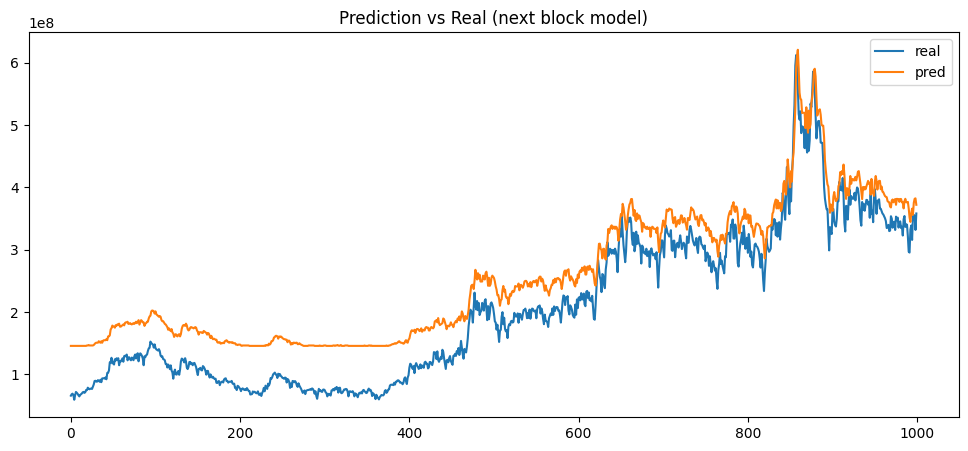

In [34]:
plt.figure(figsize=(12,5))
plt.plot(y_test_1block.values[:1000], label="real")
plt.plot(lgbm_pred[:1000], label="pred")
plt.legend()
plt.title("Prediction vs Real (next block model)")
plt.show()

In [41]:
joblib.dump(lgbm_model, 'models/next_block_lgbm_model.pkl')

['models/next_block_lgbm_model.pkl']

XGBoost

In [35]:
xgboost = XGBRegressor(
    n_estimators=5000,
    learning_rate=0.05,
    max_depth=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method="hist",
    eval_metric="rmse",   
    early_stopping_rounds=50
)

model.fit(
    X_train_1block,
    y_train_1block,
    eval_set=[(X_val_1block, y_val_1block)],
    verbose=25
)

[0]	validation_0-rmse:1441669067.96740
[25]	validation_0-rmse:666822756.53079
[50]	validation_0-rmse:680129949.43738
[75]	validation_0-rmse:688752583.04952
[80]	validation_0-rmse:688090468.38215


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",50
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fr

In [37]:
pred = model.predict(X_test_1block)

mae = mean_absolute_error(y_test_1block, pred)
rmse = np.sqrt(mean_squared_error(y_test_1block, pred))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 183975256.1169506
RMSE: 198062751.44222742


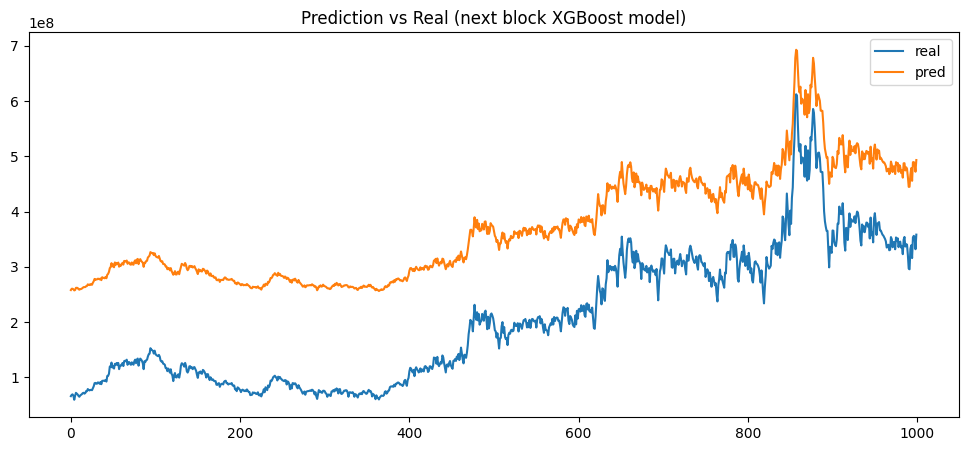

In [39]:
plt.figure(figsize=(12,5))
plt.plot(y_test_1block.values[:1000], label="real")
plt.plot(pred[:1000], label="pred")
plt.legend()
plt.title("Prediction vs Real (next block XGBoost model)")
plt.show()

## Модель прогноза комиссии через 10 минут

In [42]:
df_10m = pd.read_parquet("data/models_datasets/10_min_learn.parquet.gzip")
df_10m.sort_values('height', ascending=True, inplace=True)
df_10m

,height,size,gas_limit,gas_used,transaction_count,base_fee_per_gas,last_eth_price,block_utilization,gas_pressure,tx_per_gas,...,base_fee_ma_10,base_fee_vol_10,base_fee_ma_20,base_fee_vol_20,base_fee_ma_50,base_fee_vol_50,base_fee_change_5,base_fee_change_20,eth_return_10m,target
50,22270718,53525,35929657,7269892,79,382951028,1624.691347,0.202337,-10694936.5,0.000011,...,382097490.5,2.160832e+07,3.874097e+08,1.990233e+07,3.933427e+08,3.073605e+07,-0.082267,-0.097391,-0.000146,398195527.0
51,22270719,40628,35964743,29406516,61,354453422,1624.691347,0.817648,11424144.5,0.000002,...,379419314.2,2.331904e+07,3.842357e+08,1.983988e+07,3.921913e+08,3.109812e+07,-0.119269,-0.151893,-0.000146,391380096.0
52,22270720,53433,35999863,10224862,212,382601318,1624.691347,0.284025,-7775069.5,0.000021,...,380807627.1,2.302254e+07,3.830058e+08,1.908971e+07,3.913234e+08,3.073889e+07,-0.049648,-0.060406,-0.000146,387867033.0
53,22270721,68021,36000000,13381157,149,361943242,1624.691347,0.371699,-4618843.0,0.000011,...,382652665.1,2.027524e+07,3.812726e+08,1.936151e+07,3.908418e+08,3.101105e+07,-0.064461,-0.087401,-0.000146,381144223.0
54,22270722,103167,36000000,30617794,291,350333805,1624.691347,0.850494,12617794.0,0.000010,...,380591443.2,2.252097e+07,3.793393e+08,2.044920e+07,3.896311e+08,3.139257e+07,-0.038675,-0.099400,-0.000146,428740449.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2617939,24888607,173725,60000000,47892205,256,36216849,2358.139827,0.798203,17892205.0,0.000005,...,37542533.9,1.918762e+06,3.892728e+07,2.586517e+06,4.242590e+07,3.846016e+06,-0.016142,-0.089065,0.002591,46880934.0
2617940,24888608,156691,60000000,36445243,205,38916846,2358.139827,0.607421,6445243.0,0.000006,...,37994451.0,1.601774e+06,3.880193e+07,2.519024e+06,4.228654e+07,3.844366e+06,0.080637,-0.060521,0.002591,47377494.0
2617941,24888609,101559,60000000,38226019,187,39961964,2358.139827,0.637100,8226019.0,0.000005,...,38327021.4,1.633385e+06,3.873716e+07,2.468726e+06,4.211878e+07,3.756385e+06,0.070684,-0.031394,0.002591,43416296.0
2617942,24888610,44677,60000000,7076279,56,41331663,2358.139827,0.117938,-22923721.0,0.000008,...,38501018.1,1.860025e+06,3.871328e+07,2.439581e+06,4.200815e+07,3.694754e+06,0.078746,-0.011424,0.002591,41948482.0


In [ ]:
drop_cols = [
    "height"
]

df_10m = df_10m.drop(columns=drop_cols)

In [43]:
train_size_10m = int(len(df_10m) * 0.8)
val_size_10m = int(len(df_10m) * 0.1)

train_10m = df_10m.iloc[:train_size_10m]
val_10m = df_10m.iloc[train_size_10m:train_size_10m + val_size_10m]
test_10m = df_10m.iloc[train_size_10m + val_size_10m:]

In [44]:
X_train_10m = train_10m.drop(columns=[target_column_name])
y_train_10m = train_10m[target_column_name]

X_val_10m = val_10m.drop(columns=[target_column_name])
y_val_10m = val_10m[target_column_name]

X_test_10m = test_10m.drop(columns=[target_column_name])
y_test_10m = test_10m[target_column_name]

In [45]:
lgbm_model_10m = LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.01,
    max_depth=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_model_10m.fit(
    X_train_10m,
    y_train_10m,
    eval_set=[(X_val_10m, y_val_10m)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(50)  # вывод каждые 50 итераций
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023209 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 7443
[LightGBM] [Info] Number of data points in the train set: 2093212, number of used features: 34
[LightGBM] [Info] Start training from score 1014174872.716246
Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 1.10622e+09	valid_0's l2: 1.22373e+18
[100]	valid_0's rmse: 9.32454e+08	valid_0's l2: 8.69471e+17
[150]	valid_0's rmse: 8.72294e+08	valid_0's l2: 7.60896e+17
[200]	valid_0's rmse: 8.30447e+08	valid_0's l2: 6.89641e+17
[250]	valid_0's rmse: 8.18805e+08	valid_0's l2: 6.70442e+17
[300]	valid_0's rmse: 8.07671e+08	valid_0's l2: 6.52332e+17
[350]	valid_0's rmse: 8.07665e+08	valid_0's l2: 6.52324e+17
Early stopping, best iteration is:
[330]	valid_0's rmse: 8.05098e+08	valid_0's l2: 6.48183e+17


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,50
,learning_rate,0.01
,n_estimators,5000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [46]:
lgbm_pred = lgbm_model_10m.predict(X_test_10m)

lgbm_mae = mean_absolute_error(y_test_10m, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test_10m, lgbm_pred))

print("MAE:", lgbm_mae)
print("RMSE:", lgbm_rmse)

MAE: 74979880.02045825
RMSE: 277016528.3324685


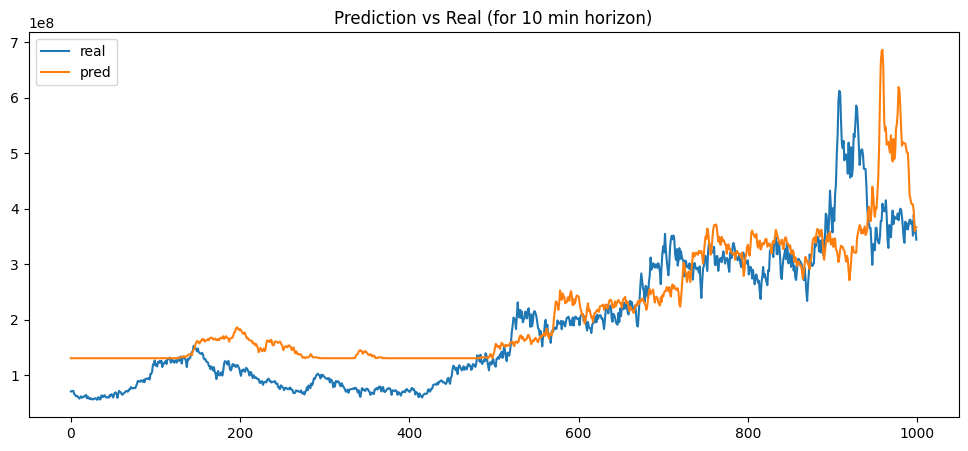

In [47]:
plt.figure(figsize=(12,5))
plt.plot(y_test_10m.values[:1000], label="real")
plt.plot(lgbm_pred[:1000], label="pred")
plt.legend()
plt.title("Prediction vs Real (for 10 min horizon)")
plt.show()

In [48]:
joblib.dump(lgbm_model_10m, 'models/10m_lgbm_model.pkl')

['models/10m_lgbm_model.pkl']

## Модель прогноза комиссии через 1 час

In [57]:
df_1h = pd.read_parquet("data/models_datasets/1_hour_learn.parquet.gzip")
df_1h.sort_values('height', ascending=True, inplace=True)
df_1h

,height,size,gas_limit,gas_used,transaction_count,base_fee_per_gas,last_eth_price,block_utilization,gas_pressure,tx_per_gas,...,base_fee_vol_50,base_fee_ma_100,base_fee_vol_100,base_fee_ma_300,base_fee_vol_300,util_ma_50,util_ma_300,eth_return_1h,eth_vol_1h,target
300,22270968,76207,35929725,15692496,187,376574486,1630.546895,0.436755,-2272366.5,0.000012,...,2.087994e+07,3.804057e+08,2.043310e+07,3.859382e+08,2.753209e+07,0.512815,0.508354,0.003457,4.652267,412115162.0
301,22270969,57619,35964811,12104936,157,370620398,1630.546895,0.336577,-5877469.5,0.000013,...,2.043990e+07,3.801920e+08,2.042245e+07,3.858002e+08,2.750464e+07,0.500134,0.507357,0.003457,4.654736,413331203.0
302,22270970,76242,35999931,31371907,179,355478445,1630.546895,0.871444,13371941.5,0.000006,...,2.082816e+07,3.800969e+08,2.051589e+07,3.855651e+08,2.746127e+07,0.507722,0.509846,0.003457,4.657128,369915102.0
303,22270971,104498,36000000,19096262,175,388488489,1629.931761,0.530452,1096262.0,0.000009,...,2.080434e+07,3.799228e+08,2.036806e+07,3.855734e+08,2.746177e+07,0.512554,0.509090,0.003079,4.658089,361679326.0
304,22270972,52046,36000000,11343043,132,391446024,1629.931761,0.315085,-6656957.0,0.000012,...,2.074810e+07,3.797799e+08,2.023480e+07,3.855086e+08,2.742481e+07,0.513623,0.508948,0.003079,4.658990,371558588.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2617689,24888357,168578,60000000,36155997,338,42320410,2364.737850,0.602600,6155997.0,0.000009,...,4.856174e+06,4.446073e+07,5.157934e+06,5.861645e+07,1.881893e+07,0.502475,0.506623,0.001700,3.525484,46880934.0
2617690,24888358,133131,60000000,20831866,146,43405927,2364.007309,0.347198,-9168134.0,0.000007,...,4.863599e+06,4.452470e+07,5.103974e+06,5.861473e+07,1.882030e+07,0.504775,0.507091,0.001391,3.500022,47377494.0
2617691,24888359,165375,60000000,40785219,290,41747797,2364.007309,0.679754,10785219.0,0.000007,...,4.859059e+06,4.458823e+07,5.028160e+06,5.861822e+07,1.881707e+07,0.502997,0.506027,0.001391,3.474339,43416296.0
2617692,24888360,155847,60000000,39679468,265,43623876,2364.007309,0.661324,9679468.0,0.000007,...,4.863522e+06,4.467378e+07,4.936495e+06,5.861102e+07,1.882240e+07,0.496519,0.505094,0.001065,3.455453,41948482.0


In [58]:
drop_cols = [
    "height"
]

df_1h = df_1h.drop(columns=drop_cols)

In [59]:
train_size_1h = int(len(df_1h) * 0.8)
val_size_1h = int(len(df_1h) * 0.1)

train_1h = df_1h.iloc[:train_size_1h]
val_1h = df_1h.iloc[train_size_1h:train_size_1h + val_size_1h]
test_1h = df_1h.iloc[train_size_1h + val_size_1h:]

In [60]:
X_train_1h = train_1h.drop(columns=[target_column_name])
y_train_1h = train_1h[target_column_name]

X_val_1h = val_1h.drop(columns=[target_column_name])
y_val_1h = val_1h[target_column_name]

X_test_1h = test_1h.drop(columns=[target_column_name])
y_test_1h = test_1h[target_column_name]

In [62]:
lgbm_model_1h = LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.01,
    max_depth=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_model_1h.fit(
    X_train_1h,
    y_train_1h,
    eval_set=[(X_val_1h, y_val_1h)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(50)  # вывод каждые 50 итераций
    ]
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.101449 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6167
[LightGBM] [Info] Number of data points in the train set: 2092814, number of used features: 29
[LightGBM] [Info] Start training from score 1014278550.077517
Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 1.34108e+09	valid_0's l2: 1.79849e+18
[100]	valid_0's rmse: 1.28767e+09	valid_0's l2: 1.65809e+18
[150]	valid_0's rmse: 1.27548e+09	valid_0's l2: 1.62686e+18
Early stopping, best iteration is:
[138]	valid_0's rmse: 1.2743e+09	valid_0's l2: 1.62384e+18


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,50
,learning_rate,0.01
,n_estimators,5000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [63]:
lgbm_pred = lgbm_model_1h.predict(X_test_1h)

lgbm_mae = mean_absolute_error(y_test_1h, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test_1h, lgbm_pred))

print("MAE:", lgbm_mae)
print("RMSE:", lgbm_rmse)

MAE: 301656444.19248253
RMSE: 580895620.2607456


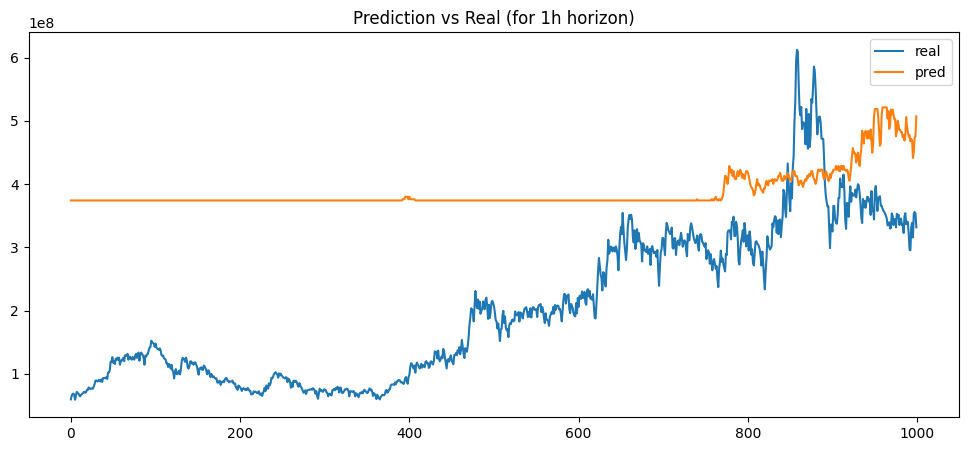

In [64]:
plt.figure(figsize=(12,5))
plt.plot(y_test_1h.values[:1000], label="real")
plt.plot(lgbm_pred[:1000], label="pred")
plt.legend()
plt.title("Prediction vs Real (for 1h horizon)")
plt.show()

In [65]:
joblib.dump(lgbm_model_1h, 'models/1h_lgbm_model.pkl')

['models/1h_lgbm_model.pkl']

## Модель прогноза комиссии через 1 день

In [91]:
df_1d = pd.read_parquet("data/models_datasets/1_day_learn.parquet.gzip")
df_1d.sort_values('height', ascending=True, inplace=True)
df_1d

,height,size,gas_limit,gas_used,transaction_count,base_fee_per_gas,last_eth_price,block_utilization,gas_pressure,tx_per_gas,...,lag_1d,lag_2d,ma_1d,ma_3d,trend_1d,vol_1d,util_ma_1d,eth_return_1d,eth_vol_1d,target
21599,22292267,145163,35999930,25725566,194,338949733,1578.949826,0.714600,7725601.0,0.000008,...,362107943.0,327197208.0,5.030380e+08,5.311891e+08,-1.640882e+08,2.987790e+08,0.507992,-0.000378,9.341392,353262945.0
21600,22292268,50809,36000000,8418032,91,357134423,1578.757829,0.233834,-9581968.0,0.000011,...,349402972.0,361923696.0,5.030391e+08,5.311882e+08,-1.459046e+08,2.987785e+08,0.507899,-0.000499,9.341548,334930250.0
21601,22292269,83913,35964845,31768885,126,333370183,1578.757829,0.883332,13786462.5,0.000004,...,384070844.0,343299868.0,5.030320e+08,5.311845e+08,-1.696618e+08,2.987819e+08,0.507991,-0.000499,9.341704,317002366.0
21602,22292270,86691,35999965,15309012,203,365318018,1578.757829,0.425251,-2690970.5,0.000013,...,357794590.0,325392167.0,5.030331e+08,5.311817e+08,-1.377150e+08,2.987814e+08,0.508013,-0.000499,9.341860,356615824.0
21603,22292271,48335,36000000,12917047,158,358491207,1578.757829,0.358807,-5082953.0,0.000012,...,337049596.0,366051608.0,5.030360e+08,5.311804e+08,-1.445448e+08,2.987798e+08,0.507935,-0.000499,9.342016,337657850.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2610789,24881457,308886,60000000,41686431,530,161605470,2321.714689,0.694774,11686431.0,0.000013,...,121470107.0,70268636.0,1.616046e+08,1.507188e+08,9.190944e+02,1.199648e+08,0.507156,-0.021441,24.478729,46880934.0
2610790,24881458,368034,60000000,49378751,1444,169474599,2321.677120,0.822979,19378751.0,0.000029,...,113001721.0,62244779.0,1.616124e+08,1.507197e+08,7.862205e+06,1.199635e+08,0.507227,-0.021457,24.481834,47377494.0
2610791,24881459,126947,60000000,20493005,353,183158790,2321.677120,0.341550,-9506995.0,0.000017,...,107668091.0,61102611.0,1.616229e+08,1.507214e+08,2.153591e+07,1.199620e+08,0.507253,-0.021457,24.484936,43416296.0
2610792,24881460,134220,60000000,24992099,662,175903417,2321.677120,0.416535,-5007901.0,0.000026,...,98456954.0,67318863.0,1.616336e+08,1.507232e+08,1.426978e+07,1.199598e+08,0.507221,-0.021457,24.488036,41948482.0


In [92]:
drop_cols = [
    "height"
]

df_1d = df_1d.drop(columns=drop_cols)

In [93]:
train_size_1d = int(len(df_1d) * 0.8)
val_size_1d = int(len(df_1d) * 0.1)

train_1d = df_1d.iloc[:train_size_1d]
val_1d = df_1d.iloc[train_size_1h:train_size_1d + val_size_1d]
test_1d = df_1d.iloc[train_size_1d + val_size_1d:]

In [94]:
X_train_1d = train_1d.drop(columns=[target_column_name])
y_train_1d = train_1d[target_column_name]

X_val_1d = df_1d.drop(columns=[target_column_name])
y_val_1d = df_1d[target_column_name]

X_test_1d = test_1d.drop(columns=[target_column_name])
y_test_1d = test_1d[target_column_name]

In [95]:
lgbm_model_1d = LGBMRegressor(
    n_estimators=5000,
    learning_rate=0.01,
    max_depth=50,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_model_1d.fit(
    X_train_1d,
    y_train_1d,
    eval_set=[(X_val_1d, y_val_1d)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(50)  # вывод каждые 50 итераций
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.018941 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4637
[LightGBM] [Info] Number of data points in the train set: 2070264, number of used features: 23
[LightGBM] [Info] Start training from score 1019931610.517079
Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 2.65761e+09	valid_0's l2: 7.06289e+18
[100]	valid_0's rmse: 2.10447e+09	valid_0's l2: 4.42879e+18
[150]	valid_0's rmse: 1.86847e+09	valid_0's l2: 3.49117e+18
[200]	valid_0's rmse: 1.71019e+09	valid_0's l2: 2.92476e+18
[250]	valid_0's rmse: 1.58909e+09	valid_0's l2: 2.52522e+18
[300]	valid_0's rmse: 1.44702e+09	valid_0's l2: 2.09387e+18
[350]	valid_0's rmse: 1.31959e+09	valid_0's l2: 1.74132e+18
[400]	valid_0's rmse: 1.23899e+09	valid_0's l2: 1.5351e+18
[450]	valid_0's rmse: 1.18149e+09	valid_0's 

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,50
,learning_rate,0.01
,n_estimators,5000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [96]:
lgbm_pred = lgbm_model_1d.predict(X_test_1d)

lgbm_mae = mean_absolute_error(y_test_1d, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test_1d, lgbm_pred))

print("MAE:", lgbm_mae)
print("RMSE:", lgbm_rmse)

MAE: 294126048.7537353
RMSE: 703535287.4671504


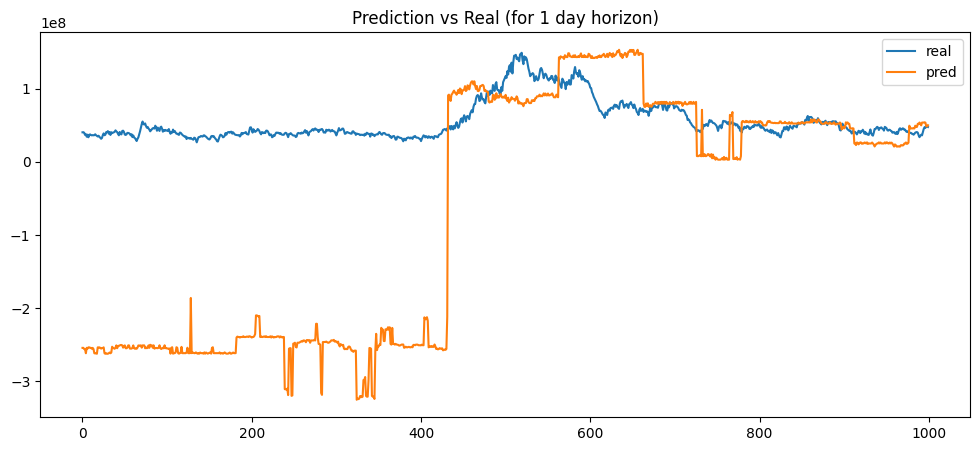

In [97]:
plt.figure(figsize=(12,5))
plt.plot(y_test_1d.values[:1000], label="real")
plt.plot(lgbm_pred[:1000], label="pred")
plt.legend()
plt.title("Prediction vs Real (for 1 day horizon)")
plt.show()

In [98]:
joblib.dump(lgbm_model_1d, 'models/1d_lgbm_model.pkl')

['models/1d_lgbm_model.pkl']

## Модель прогноза комиссии через 1 неделю

In [99]:
df_1w = pd.read_parquet("data/models_datasets/1_week_learn.parquet.gzip")
df_1w.sort_values('height', ascending=True, inplace=True)
df_1w

,height,size,gas_limit,gas_used,transaction_count,base_fee_per_gas,last_eth_price,block_utilization,gas_pressure,tx_per_gas,...,ma_7d,trend_week,vol_1d,vol_7d,util_ma_1d,util_ma_7d,eth_return_7d,eth_vol_7d,week_of_year,target
100800,22371468,63663,35964572,10703512,97,372235446,1799.359939,0.297613,-7278774.0,0.000009,...,1.239467e+09,-6.484138e+08,3.105973e+08,1.965362e+09,0.507164,0.507515,0.150862,56.066800,18,546795776.0
100801,22371469,73045,35929452,14409638,182,353401511,1799.359939,0.401054,-3555088.0,0.000013,...,1.239467e+09,-6.484200e+08,3.106014e+08,1.965362e+09,0.507158,0.507514,0.150862,56.059345,18,525035778.0
100802,22371470,105573,35894366,34485894,232,344659564,1799.359939,0.960761,16538711.0,0.000007,...,1.239468e+09,-6.484265e+08,3.106060e+08,1.965362e+09,0.507219,0.507515,0.150862,56.051888,18,559928275.0
100803,22371471,85948,35859314,16422027,144,384360954,1802.169456,0.457957,-1507630.0,0.000009,...,1.239468e+09,-6.484279e+08,3.106067e+08,1.965362e+09,0.507214,0.507514,0.152659,56.044459,18,549439320.0
100804,22371472,104689,35824297,17531609,176,380321041,1802.169456,0.489378,-380539.5,0.000010,...,1.239468e+09,-6.484296e+08,3.106077e+08,1.965362e+09,0.507230,0.507516,0.151866,56.037108,18,522987628.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2567589,24838257,64978,59941408,10529477,94,61327503,2184.525371,0.175663,-19441227.0,0.000009,...,1.376806e+08,8.525464e+07,1.488094e+08,8.420682e+07,0.504623,0.506958,0.021069,64.580273,15,46880934.0
2567590,24838258,113700,59999943,16055434,258,56354806,2184.525371,0.267591,-13944537.5,0.000016,...,1.376784e+08,8.520554e+07,1.488031e+08,8.420747e+07,0.504639,0.506954,0.021069,64.581127,15,47377494.0
2567591,24838259,263557,60000000,42885716,458,53080463,2184.525371,0.714762,12885716.0,0.000011,...,1.376760e+08,8.516113e+07,1.488036e+08,8.420819e+07,0.504716,0.506967,0.021069,64.581982,15,43416296.0
2567592,24838260,264652,60000000,59940249,98,55930378,2184.525371,0.999004,29940249.0,0.000002,...,1.376741e+08,8.512132e+07,1.488083e+08,8.420895e+07,0.504834,0.506974,0.021049,64.582836,15,41948482.0


In [100]:
drop_cols = [
    "height"
]

df_1w = df_1w.drop(columns=drop_cols)

In [101]:
train_size_1w = int(len(df_1w) * 0.8)
val_size_1w = int(len(df_1w) * 0.1)

train_1w = df_1w.iloc[:train_size_1w]
val_1w = df_1w.iloc[train_size_1w:train_size_1w + val_size_1w]
test_1w = df_1w.iloc[train_size_1w + val_size_1w:]

In [102]:
X_train_1w = train_1w.drop(columns=[target_column_name])
y_train_1w = train_1w[target_column_name]

X_val_1w = val_1w.drop(columns=[target_column_name])
y_val_1w = val_1w[target_column_name]

X_test_1w = test_1w.drop(columns=[target_column_name])
y_test_1w = test_1w[target_column_name]

In [103]:
lgbm_model_1w = LGBMRegressor(
    n_estimators=50000,
    learning_rate=0.01,
    max_depth=30,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

lgbm_model_1w.fit(
    X_train_1w,
    y_train_1w,
    eval_set=[(X_val_1w, y_val_1w)],
    eval_metric="rmse",
    callbacks=[
        early_stopping(stopping_rounds=50),
        log_evaluation(50)  # вывод каждые 50 итераций
    ]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.023673 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5441
[LightGBM] [Info] Number of data points in the train set: 1972396, number of used features: 27
[LightGBM] [Info] Start training from score 1035571762.571911
Training until validation scores don't improve for 50 rounds
[50]	valid_0's rmse: 8.10054e+08	valid_0's l2: 6.56188e+17
[100]	valid_0's rmse: 9.02698e+08	valid_0's l2: 8.14864e+17
Early stopping, best iteration is:
[58]	valid_0's rmse: 7.99473e+08	valid_0's l2: 6.39156e+17


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,30
,learning_rate,0.01
,n_estimators,50000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [104]:
lgbm_pred = lgbm_model_1w.predict(X_test_1w)

lgbm_mae = mean_absolute_error(y_test_1w, lgbm_pred)
lgbm_rmse = np.sqrt(mean_squared_error(y_test_1w, lgbm_pred))

print("MAE:", lgbm_mae)
print("RMSE:", lgbm_rmse)

MAE: 737530391.1968544
RMSE: 848217480.5908898


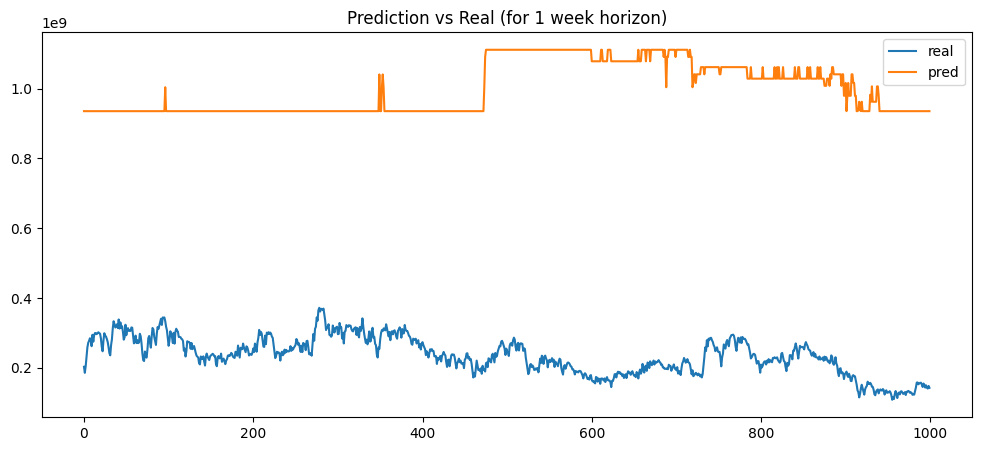

In [105]:
plt.figure(figsize=(12,5))
plt.plot(y_test_1w.values[:1000], label="real")
plt.plot(lgbm_pred[:1000], label="pred")
plt.legend()
plt.title("Prediction vs Real (for 1 week horizon)")
plt.show()

In [106]:
joblib.dump(lgbm_model_1w, 'models/1w_lgbm_model.pkl')

['models/1w_lgbm_model.pkl']